In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("Iris.csv")
data

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [3]:
data.drop('Id', axis=1, inplace=True)

In [4]:
x = data.drop('Species', axis=1)
y = data['Species']

In [5]:
from sklearn.preprocessing import StandardScaler

In [6]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [7]:
x_scaled

array([[-9.00681170e-01,  1.03205722e+00, -1.34127240e+00,
        -1.31297673e+00],
       [-1.14301691e+00, -1.24957601e-01, -1.34127240e+00,
        -1.31297673e+00],
       [-1.38535265e+00,  3.37848329e-01, -1.39813811e+00,
        -1.31297673e+00],
       [-1.50652052e+00,  1.06445364e-01, -1.28440670e+00,
        -1.31297673e+00],
       [-1.02184904e+00,  1.26346019e+00, -1.34127240e+00,
        -1.31297673e+00],
       [-5.37177559e-01,  1.95766909e+00, -1.17067529e+00,
        -1.05003079e+00],
       [-1.50652052e+00,  8.00654259e-01, -1.34127240e+00,
        -1.18150376e+00],
       [-1.02184904e+00,  8.00654259e-01, -1.28440670e+00,
        -1.31297673e+00],
       [-1.74885626e+00, -3.56360566e-01, -1.34127240e+00,
        -1.31297673e+00],
       [-1.14301691e+00,  1.06445364e-01, -1.28440670e+00,
        -1.44444970e+00],
       [-5.37177559e-01,  1.49486315e+00, -1.28440670e+00,
        -1.31297673e+00],
       [-1.26418478e+00,  8.00654259e-01, -1.22754100e+00,
      

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.3, random_state=42)

In [10]:
from sklearn.neighbors import KNeighborsClassifier

In [11]:
from sklearn.metrics import accuracy_score

In [12]:
k_values = range(1, 11)
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    y_pred = knn.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"K={k}, Accuracy: {acc:.2f}")

K=1, Accuracy: 0.98
K=2, Accuracy: 0.98
K=3, Accuracy: 1.00
K=4, Accuracy: 0.98
K=5, Accuracy: 1.00
K=6, Accuracy: 1.00
K=7, Accuracy: 1.00
K=8, Accuracy: 1.00
K=9, Accuracy: 1.00
K=10, Accuracy: 1.00


In [13]:
best_k = 3
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(x_train, y_train)
y_pred = knn.predict(x_test)

In [14]:
from sklearn.metrics import confusion_matrix

In [15]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


In [16]:
x_vis = x_scaled[:, :2]
x_vis_train, x_vis_test, y_vis_train, y_vis_test = train_test_split(x_vis, y, test_size=0.3, random_state=42)
knn_vis = KNeighborsClassifier(n_neighbors=best_k)
knn_vis.fit(x_vis_train, y_vis_train)

KNeighborsClassifier(n_neighbors=3)

In [17]:
import numpy as np

In [18]:
h = .02
x_min, x_max = x_vis[:, 0].min() - 1, x_vis[:, 0].max() + 1
y_min, y_max = x_vis[:, 1].min() - 1, x_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

In [19]:
z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
z = z.reshape(xx.shape)

In [20]:
from sklearn.preprocessing import LabelEncoder

In [21]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [24]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

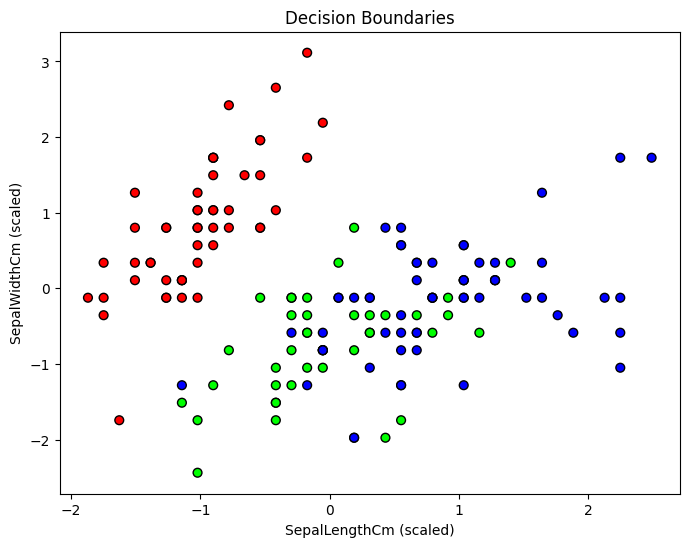

In [25]:
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

plt.figure(figsize=(8, 6))
plt.scatter(x_scaled[:, 0], x_scaled[:, 1], c=y_encoded, cmap=cmap_bold, edgecolor='k', s=40)
plt.xlabel('SepalLengthCm (scaled)')
plt.ylabel('SepalWidthCm (scaled)')
plt.title("Decision Boundaries")
plt.show()